In [1]:
import pandas as pd
import datetime as dt

In [2]:
df_google_trends = pd.read_csv("data/google_trends_data.csv").set_index("date")
df_google_trends

,pédantix,pedantix,cémantix,cemantix
date,,,,
2022-01-13,0.0,0.0,0.0,0.0
2022-01-14,0.0,0.0,0.0,0.0
2022-01-15,0.0,0.0,0.0,0.0
2022-01-16,0.0,0.0,0.0,0.0
2022-01-17,0.0,0.0,0.0,0.0
...,...,...,...,...
2026-02-12,17.0,23.0,25.0,76.0
2026-02-13,12.0,17.0,22.0,71.0
2026-02-14,2.0,4.0,6.0,25.0


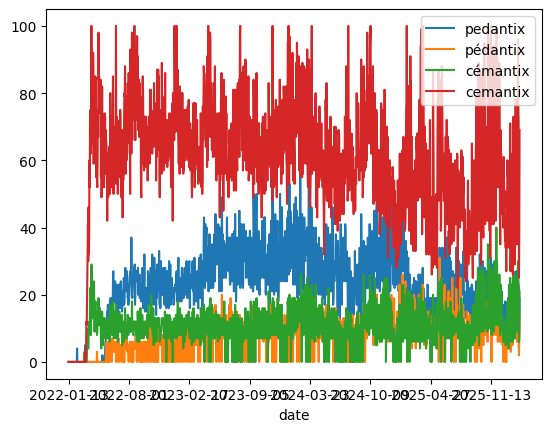

In [3]:
df_google_trends.plot(y=["pedantix", "pédantix", "cémantix", "cemantix"]);

In [4]:
df_winners = pd.read_csv('data/solvers.txt', sep="\t", header = None)
df_winners.columns = ['Numéro', 'Solvers', 'Page']
#today = dt.date(year = 2025, month = 12, day = 3)
#today_nr = 1300
date_col = pd.date_range(
    start="2022-05-14", end="2026-02-16", freq="D", inclusive="both"
) #[today - dt.timedelta(1300 - number) for number in df_winners.Numéro]
df_winners['date'] = date_col

df_winners = df_winners.set_index("date")
df_winners

,Numéro,Solvers,Page
date,,,
2022-05-14,1,4398,Affaire Dreyfus
2022-05-15,2,6632,Nestlé
2022-05-16,3,9224,Formation et évolution du Système solaire
2022-05-17,4,13865,Strasbourg
2022-05-18,5,11130,Processeur
...,...,...,...
2026-02-12,1371,35355,Information
2026-02-13,1372,35374,Homme de Néandertal
2026-02-14,1373,16067,Chamaeleonidae


In [5]:
df_google_trends.index = pd.to_datetime(df_google_trends.index)
df_winners.index = pd.to_datetime(df_winners.index)

merged_inner = df_winners.join(df_google_trends, how="inner")
merged_inner = merged_inner.rename(columns={"Solvers":"winners", "Page":"page", "Numéro":"number"})
merged_inner

,number,winners,page,pédantix,pedantix,cémantix,cemantix
date,,,,,,,
2022-05-14,1,4398,Affaire Dreyfus,0.0,3.0,8.0,73.0
2022-05-15,2,6632,Nestlé,0.0,6.0,7.0,56.0
2022-05-16,3,9224,Formation et évolution du Système solaire,0.0,6.0,12.0,69.0
2022-05-17,4,13865,Strasbourg,3.0,8.0,12.0,66.0
2022-05-18,5,11130,Processeur,4.0,12.0,12.0,65.0
...,...,...,...,...,...,...,...
2026-02-12,1371,35355,Information,17.0,23.0,25.0,76.0
2026-02-13,1372,35374,Homme de Néandertal,12.0,17.0,22.0,71.0
2026-02-14,1373,16067,Chamaeleonidae,2.0,4.0,6.0,25.0


In [6]:
import numpy as np

idx = pd.to_datetime(merged_inner.index).normalize()

holidays = [
    [dt.date(year = 2022, month = 7, day = 6),
    dt.date(year = 2022, month = 9, day = 1)],
    [dt.date(year = 2022, month = 10, day = 22),
    dt.date(year = 2022, month = 11, day = 7)],
    [dt.date(year = 2022, month = 12, day = 17),
    dt.date(year = 2023, month = 1, day = 3)],
    [dt.date(year = 2023, month = 2, day = 4),
    dt.date(year = 2023, month = 3, day = 6)],
    [dt.date(year = 2023, month = 4, day = 8),
    dt.date(year = 2023, month = 5, day = 9)],
    [dt.date(year = 2023, month = 7, day = 8),
    dt.date(year = 2023, month = 9, day = 4)],
    [dt.date(year = 2023, month = 10, day = 21),
    dt.date(year = 2023, month = 11, day = 6)],
    [dt.date(year = 2023, month = 12, day = 23),
    dt.date(year = 2024, month = 1, day = 8)],
    [dt.date(year = 2024, month = 2, day = 10),
    dt.date(year = 2024, month = 3, day = 11)],
    [dt.date(year = 2024, month = 4, day = 6),
    dt.date(year = 2024, month = 4, day = 29)],
    [dt.date(year = 2024, month = 7, day = 6),
    dt.date(year = 2024, month = 9, day = 2)],
    [dt.date(year = 2024, month = 10, day = 19),
    dt.date(year = 2024, month = 11, day = 4)],
    [dt.date(year = 2024, month = 12, day = 21),
    dt.date(year = 2025, month = 1, day = 6)],
    [dt.date(year = 2025, month = 2, day = 8),
    dt.date(year = 2025, month = 3, day = 10)],
    [dt.date(year = 2025, month = 4, day = 5),
    dt.date(year = 2025, month = 4, day = 28)],
    [dt.date(year = 2025, month = 7, day = 5),
    dt.date(year = 2025, month = 9, day = 1)],
    [dt.date(year = 2025, month = 10, day = 18),
    dt.date(year = 2025, month = 11, day = 3)],
]

starts = pd.to_datetime([s for s, e in holidays])
ends   = pd.to_datetime([e for s, e in holidays])

is_holiday = np.zeros(len(merged_inner), dtype=bool)
for s, e in zip(starts, ends):
    is_holiday |= (idx >= s) & (idx <= e)   # inclusive bounds

merged_inner["is_holiday"] = is_holiday
merged_inner

,number,winners,page,pédantix,pedantix,cémantix,cemantix,is_holiday
date,,,,,,,,
2022-05-14,1,4398,Affaire Dreyfus,0.0,3.0,8.0,73.0,False
2022-05-15,2,6632,Nestlé,0.0,6.0,7.0,56.0,False
2022-05-16,3,9224,Formation et évolution du Système solaire,0.0,6.0,12.0,69.0,False
2022-05-17,4,13865,Strasbourg,3.0,8.0,12.0,66.0,False
2022-05-18,5,11130,Processeur,4.0,12.0,12.0,65.0,False
...,...,...,...,...,...,...,...,...
2026-02-12,1371,35355,Information,17.0,23.0,25.0,76.0,False
2026-02-13,1372,35374,Homme de Néandertal,12.0,17.0,22.0,71.0,False
2026-02-14,1373,16067,Chamaeleonidae,2.0,4.0,6.0,25.0,False


In [7]:
daily_visit = pd.read_csv("data/similar_web_daily.csv", sep=";", header=None, dtype=float, decimal=",")

start = "2025-11-01"
end   = "2026-01-31"

days = pd.date_range(start=start, end=end, freq="D", inclusive="both")
daily_visit["date"] = days
daily_visit = daily_visit.set_index("date")
daily_visit["visitor"] = round(daily_visit[1]).astype(int)
daily_visit = daily_visit.drop(columns=[0, 1])
daily_visit

,visitor
date,
2025-11-01,26957
2025-11-02,30000
2025-11-03,47391
2025-11-04,43913
2025-11-05,44348
...,...
2026-01-27,74348
2026-01-28,56087
2026-01-29,54348


In [8]:
merged_inner.join(daily_visit, how="outer").to_csv("data/cleaned_data.csv")